# LEGGIAMO IL DATABASE

---

A quanto pare python può leggere i file `.mat`

In [2]:
from scipy import io as s_io
mat = s_io.loadmat('data/spectra.mat')

In [3]:
mat

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Mon Nov 26 21:14:35 2007',
 '__version__': '1.0',
 '__globals__': [],
 'Description': array(['== Spectral and octane data of gasoline ==                              ',
        '                                                                        ',
        'NIR spectra and octane numbers of 60 gasoline samples                   ',
        '                                                                        ',
        'NIR:     NIR spectra, measured in 2 nm intervals from 900 nm to 1700 nm ',
        'octane:  octane numbers                                                 ',
        'spectra: a dataset array containing variables for NIR and octane        ',
        '                                                                        ',
        'Reference:                                                              ',
        'Kalivas, John H., "Two Data Sets of Near Infrared Spectra," Chemometrics',
      

In [4]:
import numpy as np

ottani = np.zeros(mat['octane'].shape[0], dtype=np.float64)
spettri = np.zeros((mat['NIR'].shape[0], mat['NIR'].shape[1]), dtype=np.float64)
for i, (o, s) in enumerate(zip(mat['octane'], mat['NIR'])):
    ottani[i] = float(mat['octane'][i][0])
    spettri[i] = s

In [5]:
# indici che ordinerebbero l'array ottano in modo crescente
indici_ordinamento = np.argsort(ottani)

# applico indici a entrambi per riordinarli in sincrono
ottano_ordinato = ottani[indici_ordinamento]
spettri_ordinati = spettri[indici_ordinamento]
ottano_ordinato

array([83.4 , 84.4 , 84.5 , 84.6 , 84.7 , 84.7 , 85.1 , 85.1 , 85.25,
       85.25, 85.3 , 85.3 , 85.4 , 85.5 , 85.5 , 86.  , 86.1 , 86.3 ,
       86.5 , 86.6 , 86.6 , 86.85, 87.  , 87.05, 87.1 , 87.15, 87.2 ,
       87.25, 87.3 , 87.6 , 87.9 , 88.  , 88.  , 88.1 , 88.1 , 88.2 ,
       88.2 , 88.25, 88.25, 88.3 , 88.35, 88.35, 88.4 , 88.4 , 88.45,
       88.45, 88.45, 88.5 , 88.55, 88.6 , 88.65, 88.65, 88.7 , 88.7 ,
       88.7 , 88.75, 88.75, 88.85, 88.9 , 89.6 ])

In [6]:
index_list= np.array([23,26,7,1,11,4])
index_list_signal=np.array([35,42,49,52,57,33])

# uso fancy indexing
test_zeros_octane = ottano_ordinato[index_list]
test_ones_octane = ottano_ordinato[index_list_signal]
test_zeros = spettri_ordinati[index_list]
test_ones  = spettri_ordinati[index_list_signal]

In [7]:
N_2 = int(ottano_ordinato.shape[0]/2)
N = 2 * N_2

# uso list comprehension ma sicuro c'è un modo migliore
train_zeros_octane = np.array([ottano_ordinato[i] for i in range(N_2) if i not in index_list])
train_ones_octane  = np.array([ottano_ordinato[i] for i in range(N_2, N) if i not in index_list_signal])

train_zeros = np.array([spettri_ordinati[i] for i in range(N_2) if i not in index_list])
train_ones  = np.array([spettri_ordinati[i] for i in range(N_2, N) if i not in index_list_signal])

In [8]:
# labels 
n = train_zeros_octane.shape[0]
m = test_zeros_octane.shape[0]

train_labels = np.concatenate((np.zeros(int(n)), np.ones(int(n))))
test_labels = np.concatenate((np.zeros(int(m)), np.ones(int(m))))

costruisco un dizionario e lo salvo con pickle

In [9]:
dizionario = {
    'train': {
        'octane': {
            'zeros': train_zeros_octane,
            'ones': train_ones_octane
        },
        'NIR': {
            'zeros': train_zeros,
            'ones': train_ones
        },
        'labels': train_labels
    },
        
    'test': {
        'octane': {
            'zeros': test_zeros_octane,
            'ones': test_ones_octane
        },
        'NIR': {
            'zeros': test_zeros,
            'ones': test_ones
        },
        'labels': test_labels
    }
}

import pickle as pkl

with open("data/ottani_NIR.pkl", 'wb') as f:
    pkl.dump(dizionario, f)

<blank>

## Plot

---

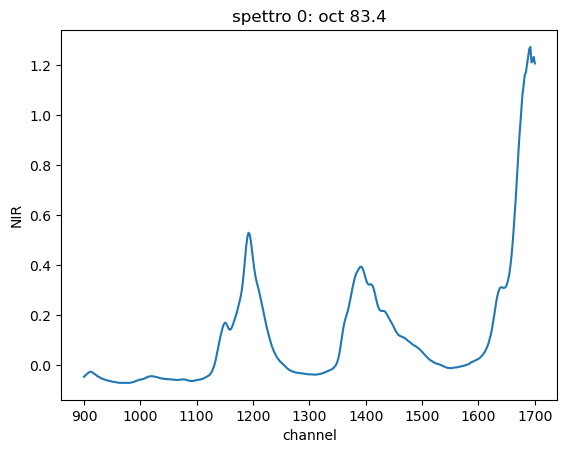

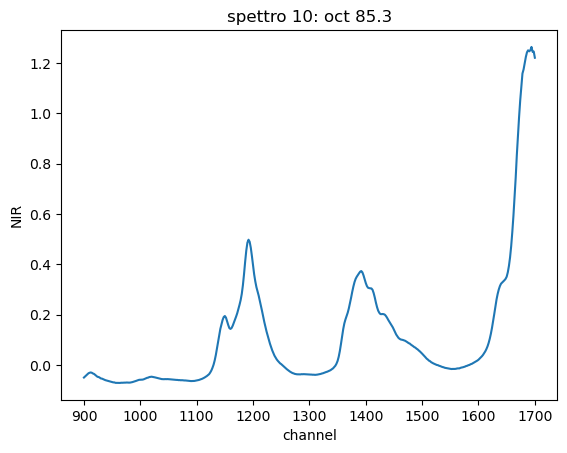

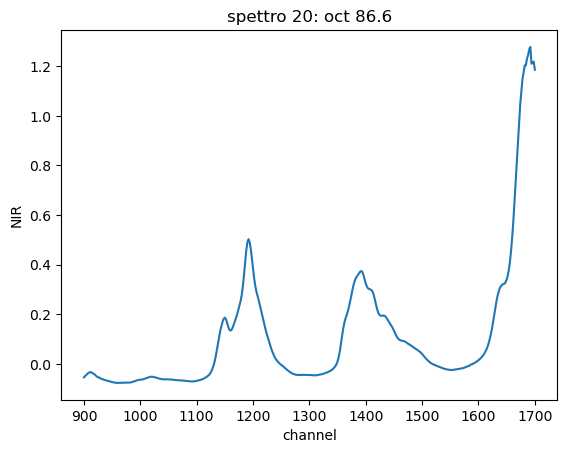

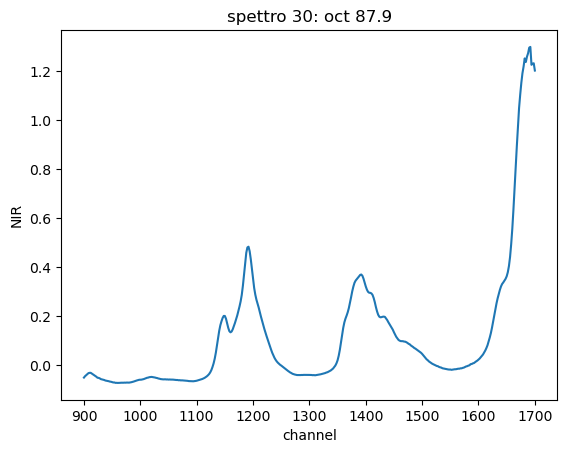

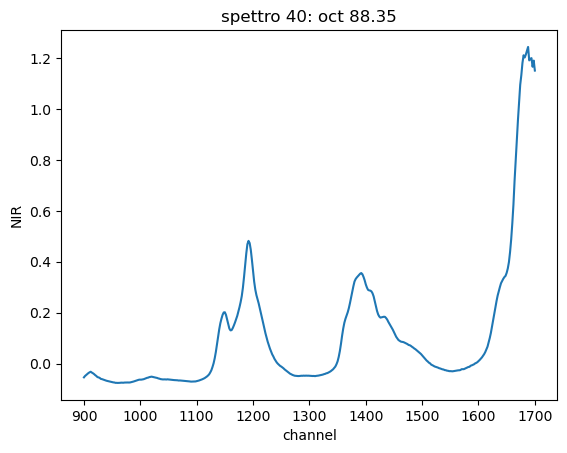

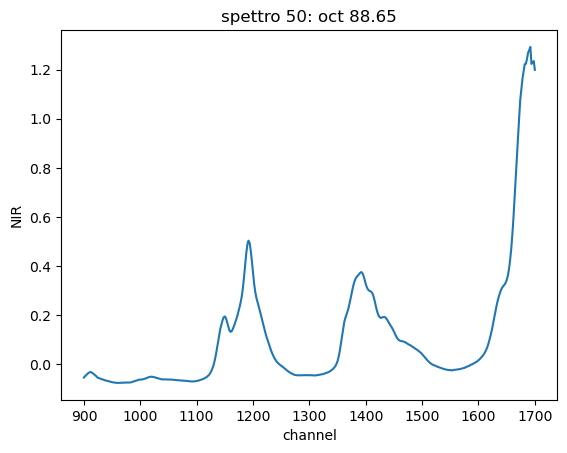

In [10]:
import matplotlib.pyplot as plt

for i in np.arange(0, 59, 10):
    x = np.arange(900, 1702, 2)
    y = spettri_ordinati[i]

    plt.plot(x,y)
    plt.xlabel("channel")
    plt.ylabel("NIR")
    plt.title(f"spettro {i}: oct {ottano_ordinato[i]}")
    plt.show()

---

## PROVE DI Savitzky-Golay SMOOTHING

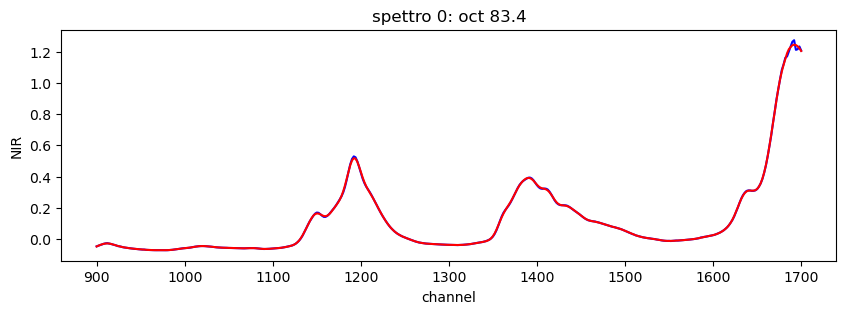

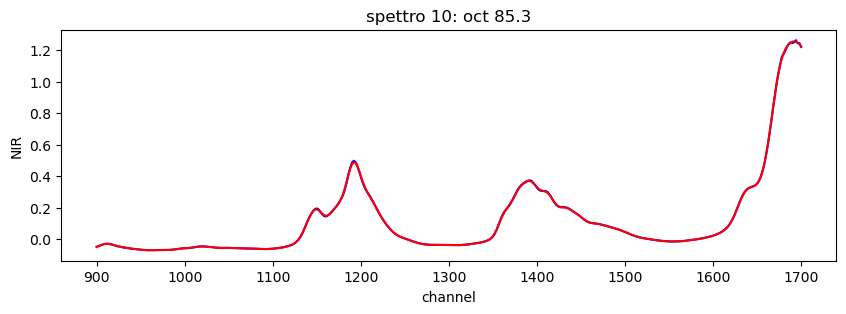

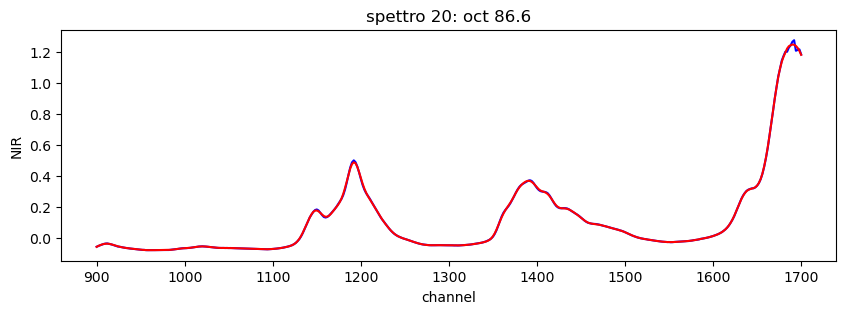

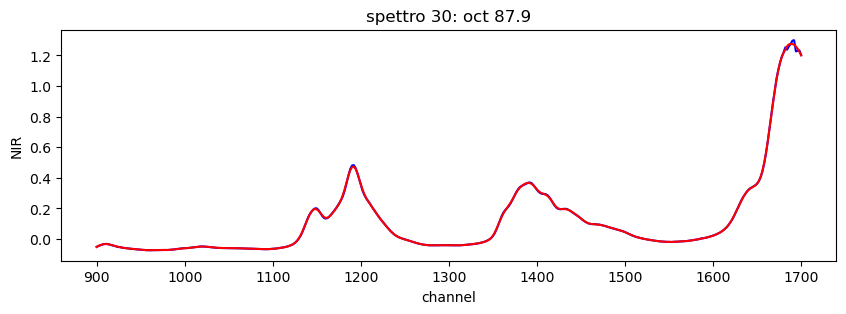

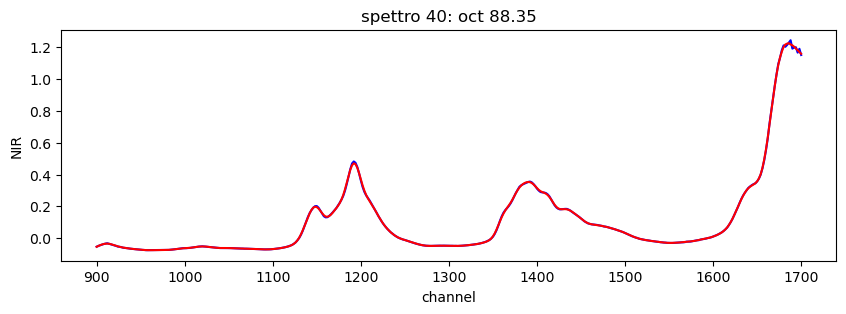

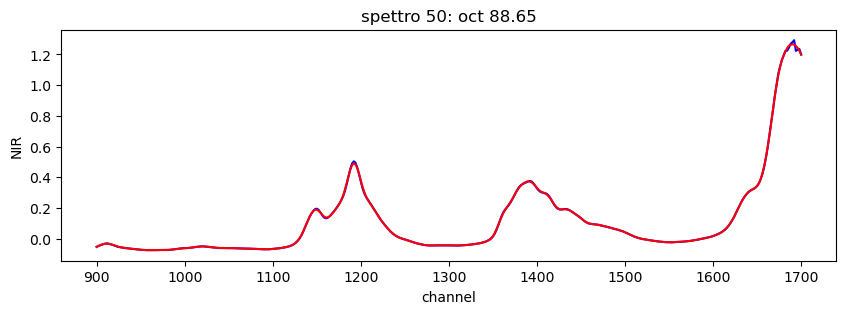

In [26]:
from scipy.signal import savgol_filter
window_size = 11
poly_order = 3
for i in np.arange(0, 59, 10):
    x = np.arange(900, 1702, 2)
    y = spettri_ordinati[i]
    y_smooth = savgol_filter(spettri_ordinati[i], window_size, poly_order)
    
    plt.figure(figsize=(10,3))
    plt.plot(x,y, label='originale', color='blue')
    plt.plot(x,y_smooth, label='smooth', color='red')
    plt.xlabel("channel")
    plt.ylabel("NIR")
    plt.title(f"spettro {i}: oct {ottano_ordinato[i]}")
    plt.show()


In [25]:
ottano_ordinato[30]

np.float64(87.9)